In [31]:
# 0. Testing file loading + understanding dataset.

import pandas as pd
df = pd.read_csv("cancer patient data sets.csv")
print(df.shape)
df.columns.tolist()

# -------------------------------------------------------------------------------------------------

# 0.1 Initial findings.

# 1000 samples/patients & 26 columns.
# Selected theme is "Demographics & Environmental Exposure", so the relevant independent variables/column names required are:
# 'Age', 'Gender', 'Air Pollution', 'Dust Allergy', 'OccuPational Hazards', 'Passive Smoker' (6 in total).

# -------------------------------------------------------------------------------------------------


(1000, 26)


['index',
 'Patient Id',
 'Age',
 'Gender',
 'Air Pollution',
 'Alcohol use',
 'Dust Allergy',
 'OccuPational Hazards',
 'Genetic Risk',
 'chronic Lung Disease',
 'Balanced Diet',
 'Obesity',
 'Smoking',
 'Passive Smoker',
 'Chest Pain',
 'Coughing of Blood',
 'Fatigue',
 'Weight Loss',
 'Shortness of Breath',
 'Wheezing',
 'Swallowing Difficulty',
 'Clubbing of Finger Nails',
 'Frequent Cold',
 'Dry Cough',
 'Snoring',
 'Level']

,Count
Level,
High,365
Medium,332
Low,303


,Age,Gender,Air Pollution,Dust Allergy,OccuPational Hazards,Passive Smoker
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,37.170000,1.400000,3.840000,5.160000,4.840000,4.200000
std,12.010000,0.490000,2.030000,1.980000,2.110000,2.310000
min,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,27.750000,1.000000,2.000000,4.000000,3.000000,2.000000
50%,36.000000,1.000000,3.000000,6.000000,5.000000,4.000000
75%,45.000000,2.000000,6.000000,7.000000,7.000000,7.000000
max,73.000000,2.000000,8.000000,8.000000,8.000000,8.000000


,Missing Values
Age,0
Gender,0
Air Pollution,0
Dust Allergy,0
OccuPational Hazards,0
Passive Smoker,0
Level,0


,Age,Gender,Air Pollution,Dust Allergy,OccuPational Hazards,Passive Smoker
Age,1.000000,-0.202000,0.099000,0.035000,0.062000,0.005000
Gender,-0.202000,1.000000,-0.247000,-0.204000,-0.192000,-0.185000
Air Pollution,0.099000,-0.247000,1.000000,0.638000,0.609000,0.607000
Dust Allergy,0.035000,-0.204000,0.638000,1.000000,0.836000,0.560000
OccuPational Hazards,0.062000,-0.192000,0.609000,0.836000,1.000000,0.555000
Passive Smoker,0.005000,-0.185000,0.607000,0.560000,0.555000,1.000000


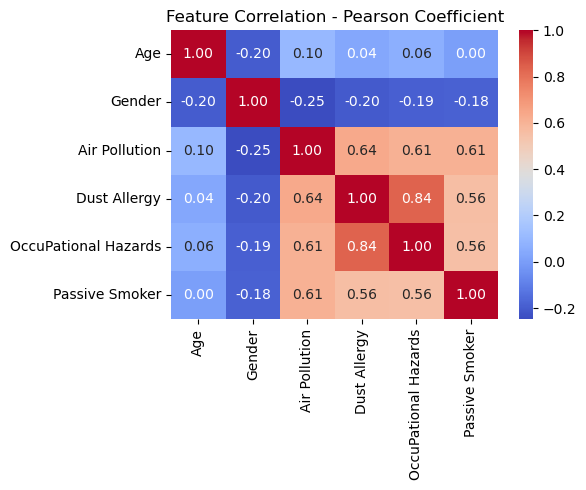

In [56]:
# 1. Class balance, descriptive stats, checking for NaN and Pearson's correlation coefficient (6 chosen variables).

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# -------------------------------------------------------------------------------------------------

# 1.1 Narrowing down my 6 selected variables.

features = ['Age', 'Gender', 'Air Pollution', 'Dust Allergy',
            'OccuPational Hazards', 'Passive Smoker']
target = 'Level'

X = df[features].copy()
y = df[target].copy()

# 1.2 Table formatting for the rest of the cell output.

def bordered(df, caption=None):
    styled = df.style.set_table_styles([
        {'selector': 'th', 'props': [('border', '1px solid black'),
                                     ('background-color', '#f0f0f0'),
                                     ('padding', '6px')]},
        {'selector': 'td', 'props': [('border', '1px solid black'),
                                     ('padding', '6px'),
                                     ('text-align', 'center')]},
    ])
    if caption:
        styled = styled.set_caption(caption)
    return styled

# -------------------------------------------------------------------------------------------------

# 1.3 Class balance.
display(bordered(y.value_counts().rename_axis('Level').to_frame('Count'),
                 "Class Balance of Target Variable (Lung Cancer Risk Level)"))

# -------------------------------------------------------------------------------------------------

# 1.4 Descriptive statistics
display(bordered(X.describe().round(2),
                 "Descriptive Statistics of Selected Features"))

# -------------------------------------------------------------------------------------------------

# 1.5 Initial findings (regarding 1.3 - 1.4).

# Class balance: 365 High / 332 Medium / 303 Low — a 1.2:1 ratio.
# Ratio is calculated as the largest class/smallest class, which is 365/303 = 1.21. A perfectly balanced split is 1:1.
# This imbalance is very mild, so opting not to resample.

# Key descriptive stats: Age is continuous, the sole numeric feature/variable, and Gender is binary (M/F) with a 60-40 split in favour of M.
# Air Pollution, Dust Allergy, OccuPational Hazards, and Passive Smoker are all categorical (ordinal) from a scale of 1-8.

# Age is right-skewed. The range is 14-73, the mean (37.2) vs median (36) — close.
# However, Q3 is only at 45, which means 75% of the patients are under 45.
# This is a limitation to consider, as lung cancer is age-driven in reality, yet this sample skews young.
# The model is mostly trained on under-45s, so it may not transfer to an older occupational workforce.

# Good variation on the 4 exposure variables, no variable would be useless for splitting, as a feature with no spread can't help a tree.

# -------------------------------------------------------------------------------------------------

# 1.6 Missing value check (good practice, as the decision tree was chosen).

display(bordered(df[features + [target]].isnull().sum().to_frame('Missing Values'),
                 "Missing Value Check"))

# Confirmed no missing data (trees can't handle NaN - an empty/missing value).
# The dataset was checked for missing values; none were present, so no imputation was required.

# -------------------------------------------------------------------------------------------------

# 1.7 Pearson's correlation coefficient.

# 1.7.1 Table.
display(bordered(X.corr().round(3),
                 "Feature Correlation Matrix (Pearson)"))

# 1.7.2 Correlation Heatmap (Appendix) - Visual Aid.
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation - Pearson Coefficient')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# We are computing the Pearson correlation coefficient between every pair of the 6 features (-1 to +1).
# Air and Gender have low correlation with nearly all the variables.
# However, the four exposure variables are moderately to highly intercorrelated. E.g. Dust Allergy & OccuPational Hazards are correlated at 0.84 (V High).

# Why this is important for the report:
# The decision tree will probably pick one of the 2 variables mentioned above to split on and ignore the other.
# This is not because Dust Allergy is less important than OccuPational Hazards, but rather the other adds little new information due to high correlation.
# Interpretation: Dust Allergy's predictive information is largely shared with Occupational Hazards (not that it isn't important).
# Good limitation to raise: correlated features don't add independent predictive value.
# No need to remove any variable, as decision trees handle correlated features fine; it is a discussion/limitation point.

# -------------------------------------------------------------------------------------------------

In [39]:
# 2. Encoding the target variable (Lung Cancer Risk Level) from text to a number.

y = df[target].copy()

level_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = y.map(level_map)

# -------------------------------------------------------------------------------------------------

# 2.1 Showing the encoded class counts as a bordered table.

encoded_counts = y.value_counts().sort_index().rename_axis('Encoded Level').to_frame('Count')
encoded_counts.index = ['0 (Low)', '1 (Medium)', '2 (High)']
display(bordered(encoded_counts, "Encoded Target Variable"))

print("Any unmapped (NaN)?", y.isna().sum())

# We are deliberately mapping Low to 0, Medium to 1, and High to 2 so that the numeric order matches the actual risk order (treated as distinct classes).
# Again double-checking that there are no empty values (NaN) - must be 0 before proceeding.

# -------------------------------------------------------------------------------------------------


,Count
0 (Low),303
1 (Medium),332
2 (High),365


Any unmapped (NaN)? 0


In [43]:
# 3. Splitting data into Train / Validation / Test.

# We have already filtered columns between teammates, we do not need to filter rows as well.
# This is because there is no missing data (NaN=0), and there is a mild class balance ratio.

# -------------------------------------------------------------------------------------------------

# 3.1 Choosing a 70/15/15 split instead of say, a 80/10/10 split.

# Large number of samples (1000) - so we can afford larger eval sets (150 in val/test - so 50 samples per class, enough to read accuracy).
# If 80/10/10 - val/test sets would be 100 each (33 per class) — workable, but:
# We choose to trade a little training data for more reliable evaluation, which matters more as we have a 3-class problem (need more eval samples to be readable).
# The dataset is near-perfectly separable, so the interesting signal is in the few misclassifications — we want enough test samples to actually see them.

# -------------------------------------------------------------------------------------------------

# The aim is to divide 1000 patients into three separate sets so the model is trained, tuned, and evaluated on different data each time.
# This prevents overfitting and gives an honest final accuracy.

# Training set (70%): Used to build the actual decision tree (learn the splits).
# Validation set (15%): Used to choose hyperparameters (e.g. max_depth).
# Test set (15%): Used once at the very end to report performance.

# Note: train_test_split can only divide data into 2 parts at a time, so we run it twice: first to remove 70%, then to halve the rest.

# -------------------------------------------------------------------------------------------------

# 3.2 Split 1: Separating 70% training from 30% (validation + test combined).

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,        # 30% goes to temp, 70% stays as training.
    random_state=42,       # Fixes the random shuffle so results are reproducible.
    stratify=y)            # Keeps Low/Med/High in the same proportions as the full data.

# Note: Stratifying is an important methodology point; it keeps the same Low/Medium/High proportions as the full dataset.
# Without it, a random split could overload one set with High-risk cases, making evaluation unfair.

# random_state=42 just sets the seed, so that anyone re-running gets an identical split.

# -------------------------------------------------------------------------------------------------

# 3.3 Split 2: Dividing the 30% temp pool in half (15% validation, 15% test).

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,        # Half of the 30% temp = 15% test, other half = 15% validation.
    random_state=42,       # Same fixed seed for reproducibility.
    stratify=y_temp)       # Again preserving class balance across val and test.

# -------------------------------------------------------------------------------------------------

# 3.4 Display the resulting split sizes (table formatting).

split_sizes = pd.DataFrame({
    'Set': ['Training', 'Validation', 'Test', 'Total'],
    'Samples': [len(X_train), len(X_val), len(X_test),
                len(X_train) + len(X_val) + len(X_test)],
    'Proportion': ['70%', '15%', '15%', '100%']
}).set_index('Set')
display(bordered(split_sizes, "Train / Validation / Test Split"))

# -------------------------------------------------------------------------------------------------


,Samples,Proportion
Set,,
Training,700,70%
Validation,150,15%
Test,150,15%
Total,1000,100%


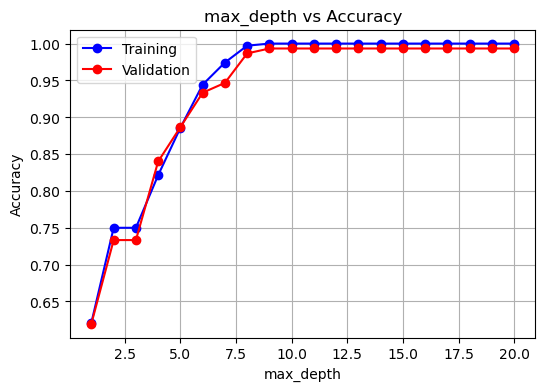

,Training Accuracy,Validation Accuracy
max_depth,,
1,0.621000,0.620000
2,0.750000,0.733000
3,0.750000,0.733000
4,0.821000,0.840000
5,0.886000,0.887000
6,0.944000,0.933000
7,0.974000,0.947000
8,0.997000,0.987000
9,1.000000,0.993000


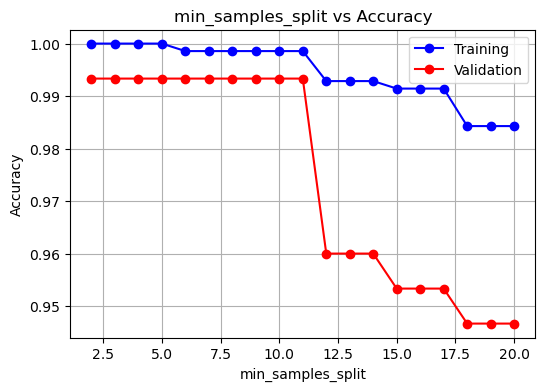

,Training Accuracy,Validation Accuracy
min_samples_split,,
2,1.000000,0.993000
3,1.000000,0.993000
4,1.000000,0.993000
5,1.000000,0.993000
6,0.999000,0.993000
7,0.999000,0.993000
8,0.999000,0.993000
9,0.999000,0.993000
10,0.999000,0.993000


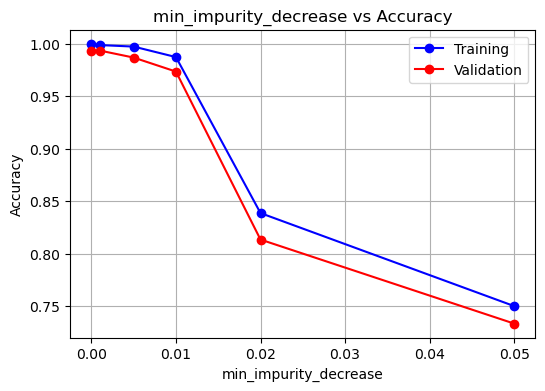

,Training Accuracy,Validation Accuracy
min_impurity_decrease,,
0.000000,1.000000,0.993000
0.001000,0.999000,0.993000
0.005000,0.997000,0.987000
0.010000,0.987000,0.973000
0.020000,0.839000,0.813000
0.050000,0.750000,0.733000


In [59]:
# 4. Hyperparameter tuning (finding settings for the decision tree's hyperparameters).

# For each hyperparameter, we train trees across a range of values, measuring the accuracy on both training and validation sets.

# Training accuracy shows how well the tree fits the data it learned from.
# Validation accuracy shows how well it generalises to unseen data.

# We pick the value where the validation accuracy peaks/plateaus.
# When training accuracy keeps rising but validation stalls or drops, that gap is the signature of overfitting.

# -------------------------------------------------------------------------------------------------

# Defining a reusable function for tuning. param_name will contain a string like 'max_depth', 'min_samples_split', and 'min_impurity_decrease'.
def tune_table(param_name, values):
    # Two empty lists to collect the accuracy scores as we go (for training and validation).
    train_acc, val_acc = [], []
    # 4.1 Loop through each candidate (e.g. depth=1, depth=2,depth=3, etc.).
    for v in values:
        # 4.1 Build a tree with this one hyperparameter set to value v.
        clf = DecisionTreeClassifier(random_state=42, **{param_name: v})
        clf.fit(X_train, y_train)                              # It learns splits from the training data only.
        train_acc.append(accuracy_score(y_train, clf.predict(X_train)))  # Accuracy on training.
        val_acc.append(accuracy_score(y_val, clf.predict(X_val)))        # Accuracy on validation.

    # 4.2 Plot training vs validation accuracy across the range of values.
    plt.figure(figsize=(6,4))
    plt.plot(list(values), train_acc, 'b-o', label='Training')
    plt.plot(list(values), val_acc, 'r-o', label='Validation')
    plt.xlabel(param_name); plt.ylabel('Accuracy')
    plt.title(f'{param_name} vs Accuracy')
    plt.legend(); plt.grid(True)
    plt.savefig(f'{param_name}_tuning.png', dpi=150, bbox_inches='tight')
    plt.show()

# -------------------------------------------------------------------------------------------------

# 4.3 Tuning each hyperparameter in turn. Tabular output.

    tbl = pd.DataFrame({
            param_name: list(values),
            'Training Accuracy': [round(a, 3) for a in train_acc],
            'Validation Accuracy': [round(a, 3) for a in val_acc]
    }).set_index(param_name)
    display(bordered(tbl, f"{param_name} Tuning Results"))

tune_table('max_depth', range(1, 21))
tune_table('min_samples_split', range(2, 21))
tune_table('min_impurity_decrease', [0, 0.001, 0.005, 0.01, 0.02, 0.05])

# -------------------------------------------------------------------------------------------------

# 4.4 Findings and takeaways.

# -------------------------------------------------------------------------------------------------

# 4.4.1 Maximum depth:

# Maximum depth is the maximum number of levels/splits in a decision tree. Each level is one more layer of yes/no splits.
# Shallow tree = few questions = simple but may underfit. Deep tree = many questions = can capture fine patterns but may overfit.

# Graph analysis:
# Accuracy climbs steeply from depth 1 (0.62) and plateaus at depth 9 (0.993), flat thereafter.
# Training (blue) and validation (red) stay glued together — they don't diverge, meaning almost no overfitting even at high depth.
# The tree simply stops finding splits after depth 9 because the data is so easily separable.

# Maximum depth to pick:
# A depth-9 tree scores 0.993 but is far too large to display or audit.
# A depth-5 tree "only" hits ~0.89 but produces a readable rule set that an occupational-health team could actually use.

# The AP1 problem is not to maximise accuracy, but rather to build a triage tool that an occupational health team can use, audit, and justify to a flagged worker.
# A model that scores 0.89 and fits on one readable page does the job better than an unreadable level 9 black box, which would fail the set use case.
# It is more important to address the design requirement, rather than choosing the model with the highest accuracy.

# So, use the depth-5 tree in the analysis, put the depth-9 tree in the appendix, and justify this choice.
# State that it is a deliberate trade-off favouring interpretability.
# Point of discussion: The 15-point accuracy gap (0.89 vs 0.99): Is ~10% accuracy worth sacrificing for full auditability?
# In a triage context, this answer is reasonably yes.
# As the model only flags people for further monitoring, the cost of a potential misflag is low compared to the value of explainability.

# -------------------------------------------------------------------------------------------------

# 4.4.2 Minimum samples split:

# It is the minimum number of samples a node needs before it's allowed to split.
# If a node has fewer than this many patients, it becomes a leaf instead of splitting further.
# Higher value = tree stops splitting earlier = simpler, more general tree.

# Graph analysis:
# Validation accuracy is flat at 0.993 from 2 up to 11, then drops off a cliff at 12 (down to 0.96, then 0.95).

# Minimum samples split to pick:
# Anywhere in 2–11 gives peak accuracy. The default 2 is fine.

# -------------------------------------------------------------------------------------------------

# 4.4.3 Minimum impurity decrease:

# This is the minimum Gini reduction required to allow a split.
# A split only happens if it reduces impurity by at least this amount.
# Higher = only "worthwhile" splits allowed = simpler tree. 0 = allow any split that helps at all.

# Graph analysis:
# Highest accuracy at 0 (0.993), essentially flat to 0.001.
# Falls sharply from 0.01 to 0.02 and then declines at a slower gradient to 0.05.
# Setting it too high blocks useful splits and the tree underfits.

# Minimum impurity decrease to pick:
# 0 (or 0.001) gives peak accuracy.

# -------------------------------------------------------------------------------------------------


,Train,Validation,Test
Model,,,
Final (depth 5),0.886000,0.887000,0.840000
Appendix (depth 9),1.000000,0.993000,0.980000


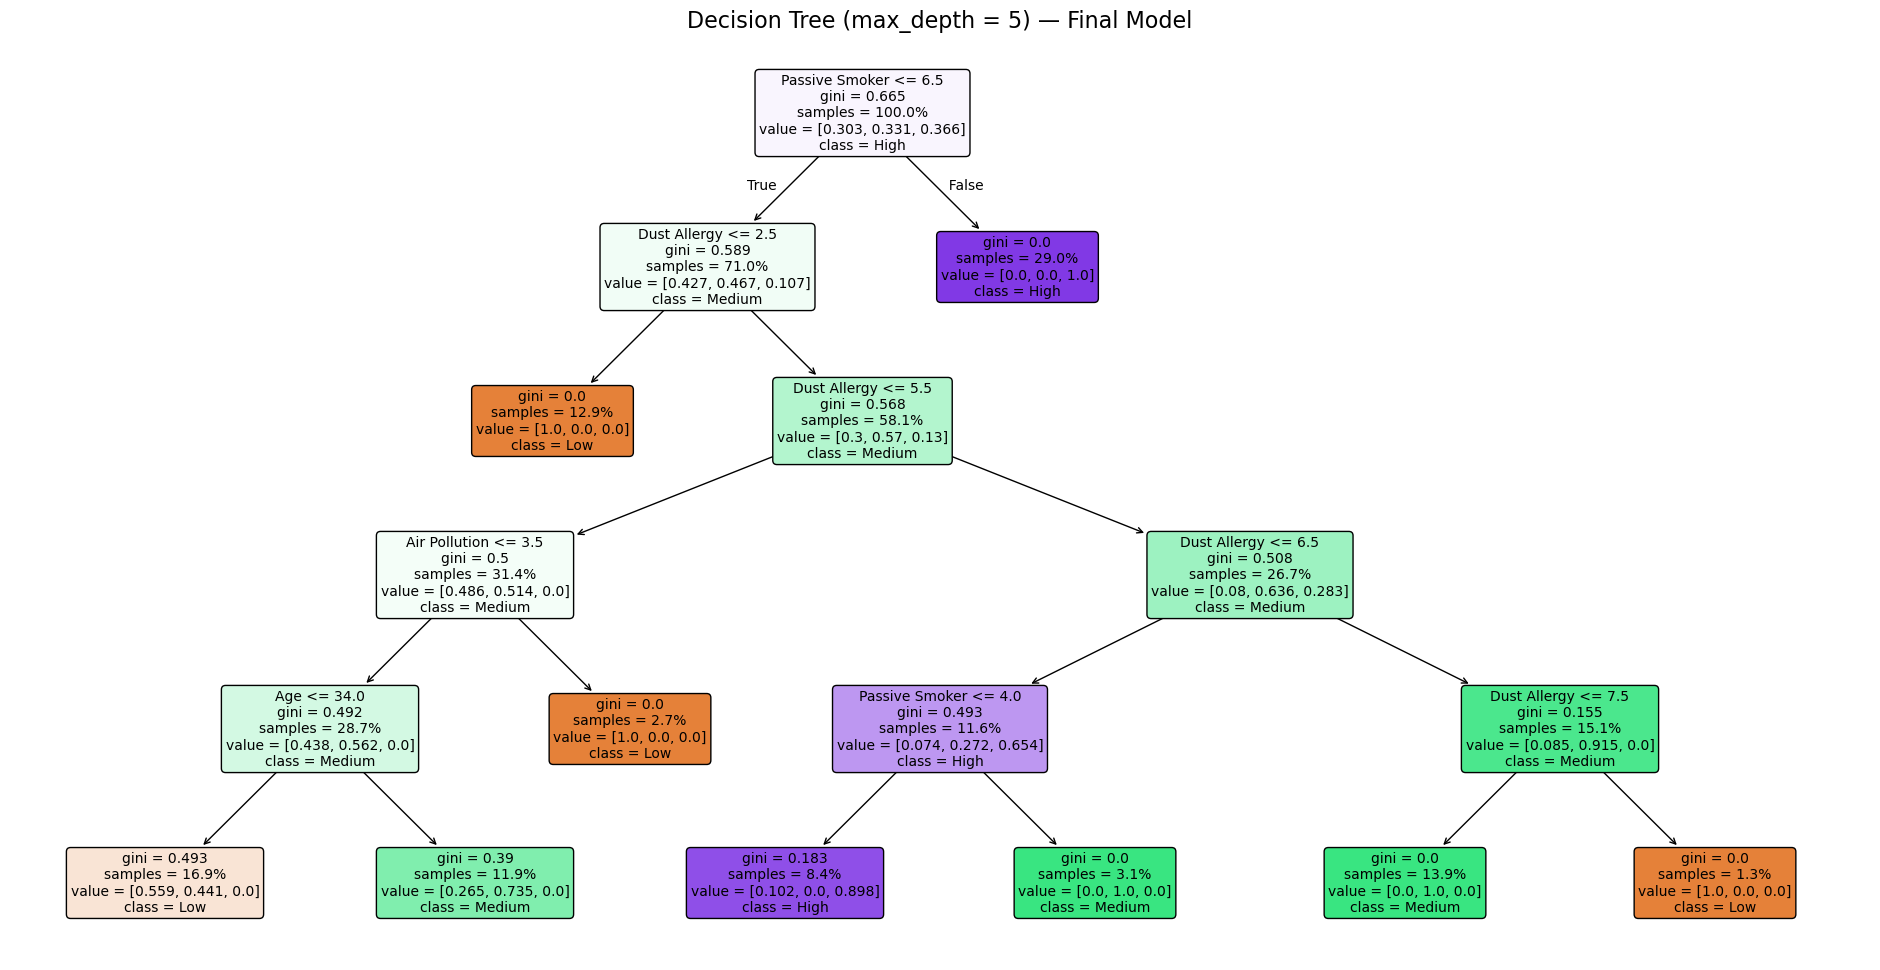

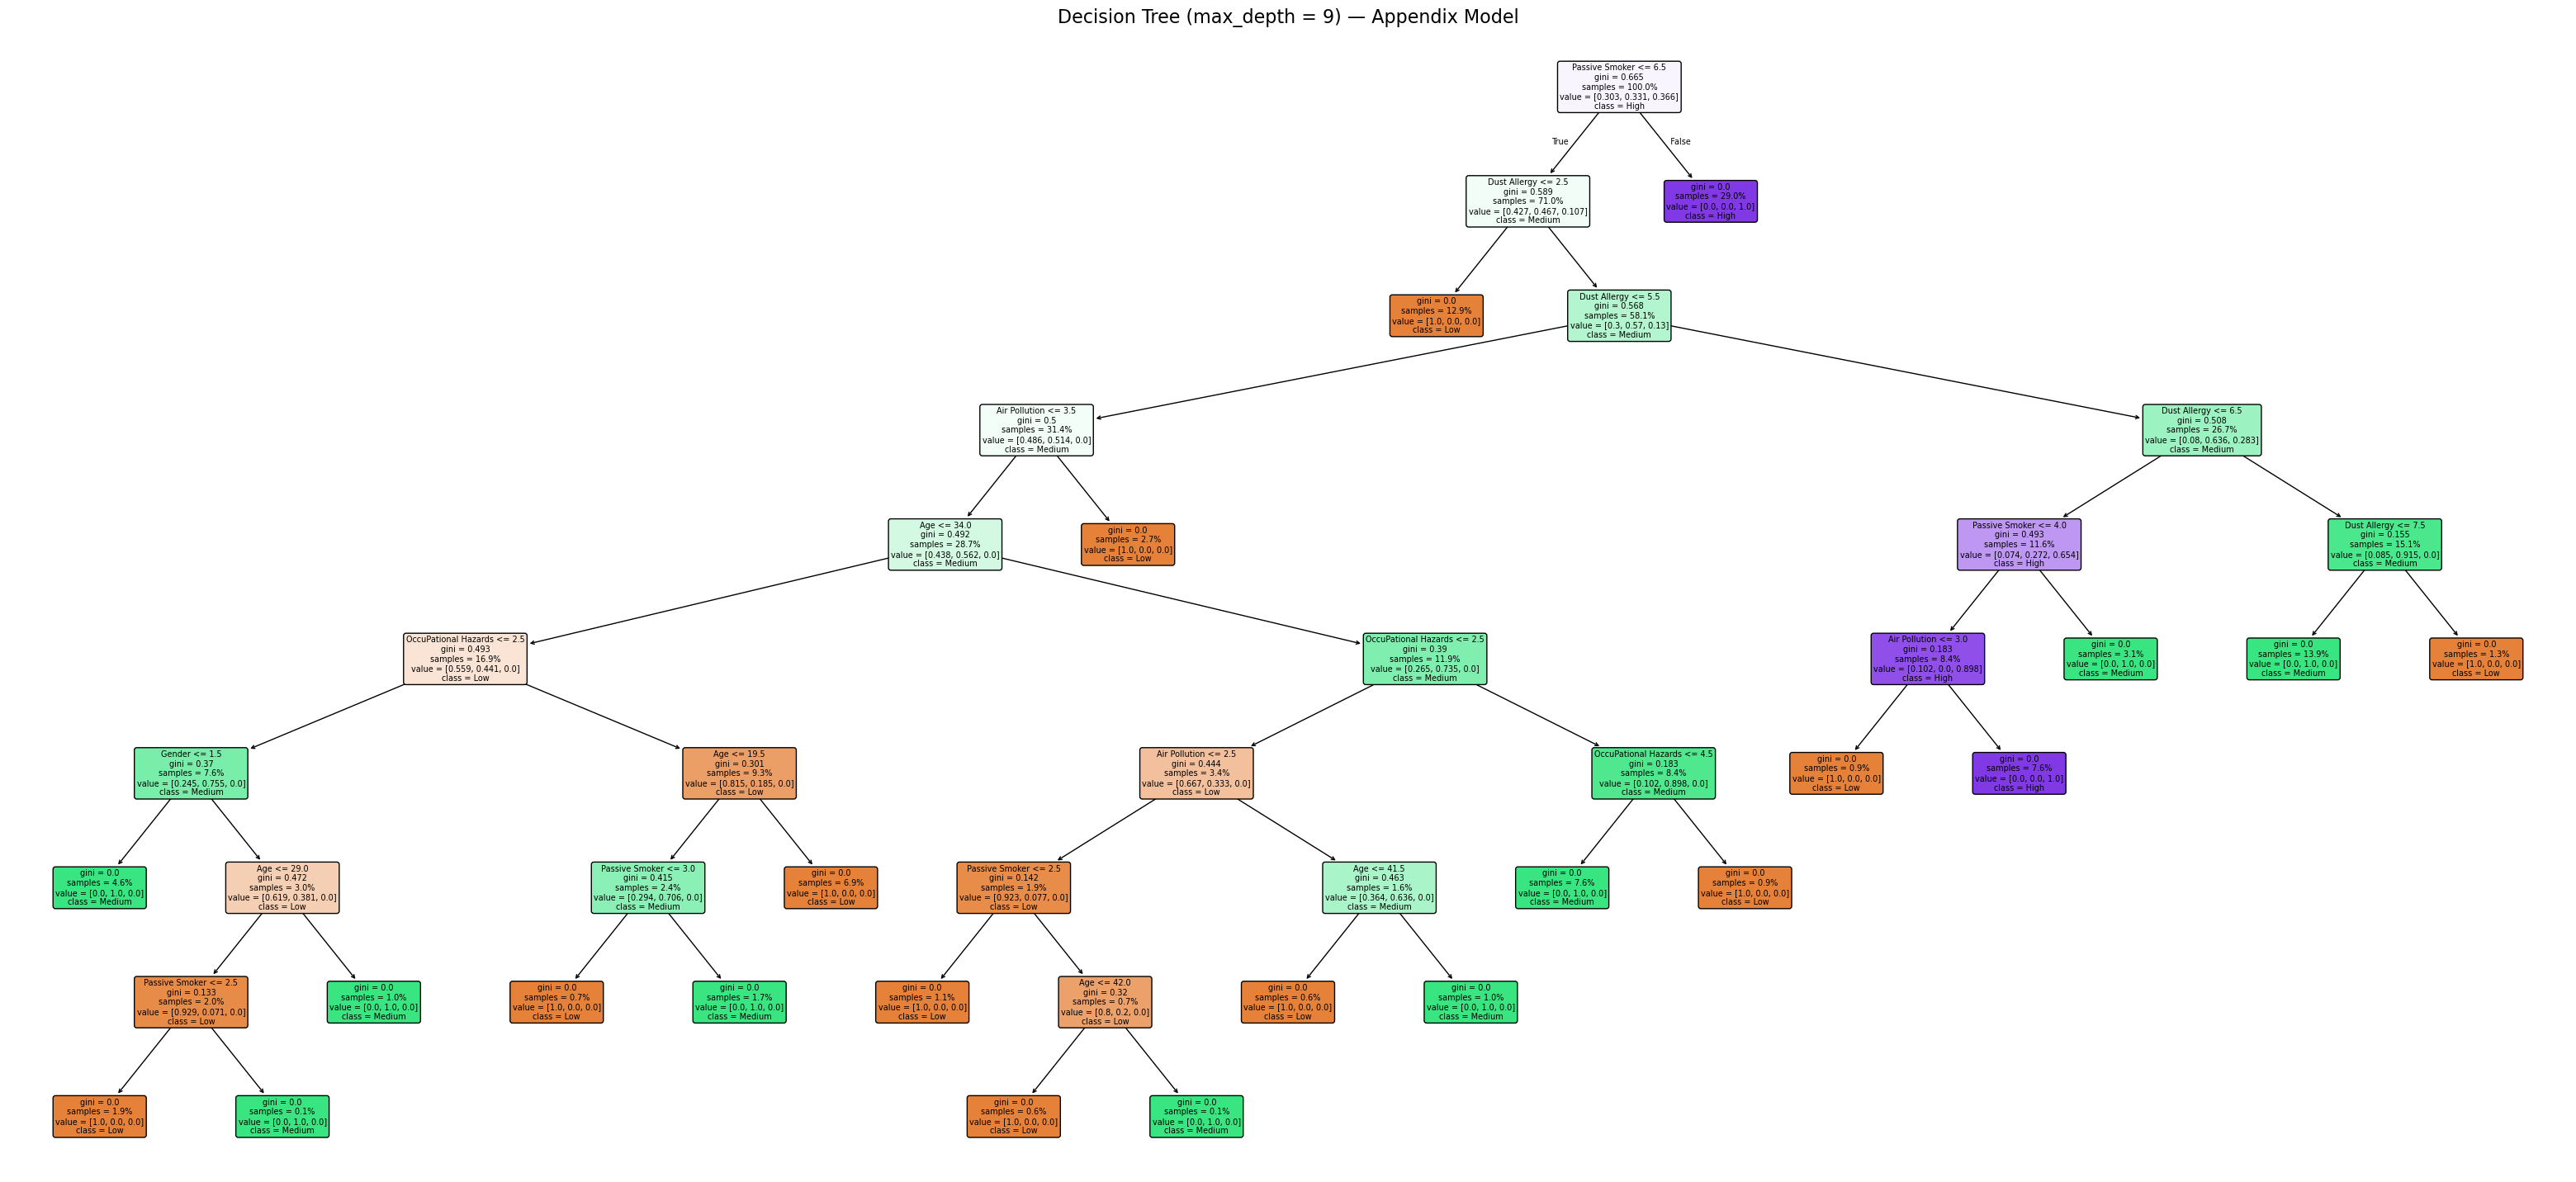

In [51]:
# 5. Final decision tree: used model (depth 4) + appendix Model (depth 9).

# Based on the tuning graphs:
# min_samples_split = 2  and  min_impurity_decrease = 0  were optimal.
# For max_depth, depth 9 gives peak accuracy (~0.99) but is too large to interpret.
# We deliberately choose depth 5 as our final model as it is fully interpretable, serving the occupational-health triage use case.
# The depth-9 model is built too, for the appendix, to evidence the accuracy/interpretability trade-off.

# -------------------------------------------------------------------------------------------------

# 5.1 Depth 5 (interpretable, reported in main text).
final = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_impurity_decrease=0,
    random_state=42)
final.fit(X_train, y_train)

# -------------------------------------------------------------------------------------------------

# 5.2 Depth 9 (accuracy-optimal, non-interpretable, in appendix).
deep = DecisionTreeClassifier(
    max_depth=9,
    min_samples_split=2,
    min_impurity_decrease=0,
    random_state=42)
deep.fit(X_train, y_train)

# -------------------------------------------------------------------------------------------------

# 5.3 Compare the accuracy of both across all three sets.
rows = []
for label, model in [('Final (depth 5)', final), ('Appendix (depth 9)', deep)]:
    rows.append({
        'Model': label,
        'Train':      round(accuracy_score(y_train, model.predict(X_train)), 3),
        'Validation': round(accuracy_score(y_val,   model.predict(X_val)),   3),
        'Test':       round(accuracy_score(y_test,  model.predict(X_test)),  3),
    })
acc_table = pd.DataFrame(rows).set_index('Model')
display(bordered(acc_table, "Accuracy: Final vs Appendix Model"))

# -------------------------------------------------------------------------------------------------

# 5.4 Results.

# Final model (depth 5): Train 0.886 / Val 0.887 / Test 0.840.
# Train and validation are almost identical (0.886 vs 0.887) — textbook no-overfitting.
# A validation to test drop is present (0.887 to 0.840).


# Appendix model (depth 9): Train 1.000 / Val 0.993 / Test 0.980.
# Near-perfect separability that was predicted.
# Train hits 1.000 (memorises training data perfectly), and even the test is 0.98.

# The interpretable depth-5 tree achieves 84.0% test accuracy versus the depth-9 tree's 98.0%. This is a 14-point cost for full auditability.
# 84% is a respectable number for a triage tool, again keeping in mind that these patients are only being flagged, not diagnosed.

# Depth 5 is still very much drawable and readable — max 32 leaves, fits on a page, an occupational-health team could follow the rules.

# -------------------------------------------------------------------------------------------------

# 5.5 Decision tree plots.

# 5.5.1 Depth 5 (main).
plt.figure(figsize=(24, 12))
plot_tree(final,
          feature_names=features,
          class_names=['Low', 'Medium', 'High'],
          filled=True,        # colour nodes by majority class
          rounded=True,
          fontsize=10,
          proportion=True)    # show class proportions (cleaner than raw counts)
plt.title('Decision Tree (max_depth = 5) — Final Model', fontsize=16)
plt.savefig('tree_depth5_final.png', dpi=200, bbox_inches='tight')
plt.show()

# 5.5.2 Depth 9 (appendix).
plt.figure(figsize=(40, 18))
plot_tree(deep,
          feature_names=features,
          class_names=['Low', 'Medium', 'High'],
          filled=True,
          rounded=True,
          fontsize=7,
          proportion=True)
plt.title('Decision Tree (max_depth = 9) — Appendix Model', fontsize=16)
plt.savefig('tree_depth9_appendix.png', dpi=200, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------------------------------

# 5.6 Depth 5 Tree Discussion.

# Root split = Passive Smoker <= 6.5 (single most important predictor).
# Looking at the False branch, we see that anyone with passive-smoking exposure above 6.5 is classified as high-risk with perfect purity (no Low/Medium).
# High passive-smoking exposure alone is a sufficient flag for high risk in this data (isolating nearly a third of the population).

# Passive Smoker <= 6.5 AND Dust Allergy <= 2.5, 12.9% of patients, gini 0.0, pure Low. Low exposure on both, so confidently Low-risk.
# The far-right Dust Allergy <= 7.5 path → 13.9%, pure Medium Risk.

# Dust Allergy dominates the rest of the tree.
# Below the root, the splits are overwhelmingly on Dust Allergy (at 2.5, 5.5, 6.5, 7.5) — it appears four times.
# This correlates back to our initial Pearson correlation coefficient findings - Dust Allergy correlated 0.84 with OccuPational Hazards.
# Therefore, we do not see OccuPational Hazards in our tree, not because it is unimportant, butbbecause it's inofrmation is largely shared.
# Mention that this earlier prediction was confirmed by the decision tree.

# The tree carves out several pure (gini = 0) leaves — confident regions — while the messier, mixed leaves (gini ~0.49) are where the 16% of errors live.

# 5.7 Misclassification (addressing the 16% of errors).

# Looking at the leaf on the bottom-left: Air Pollution <= 3.5 → Age <= 34.0: 16.9% of patients, gini = 0.493, value = [0.559, 0.441, 0.0], class = Low.
# This leaf is almost a 56/44 coin flip between Low and Medium.
# The tree calls it "Low" because Low is the slight majority, but it's genuinely uncertain.
# This is exactly where the model's errors concentrate, the Low to Medium boundary, among younger patients with low air pollution.

# Note that High never appears in this confused region.
# The High-risk cases are cleanly separated (the pure purple High leaves), while the ambiguity is all Low-vs-Medium.
# For a triage tool, this is reassuring — the model rarely confuses high-risk with low-risk, which are the most costly errors to make.

# Note: Darker shades - more confident, paler shades - less confident.

# -------------------------------------------------------------------------------------------------


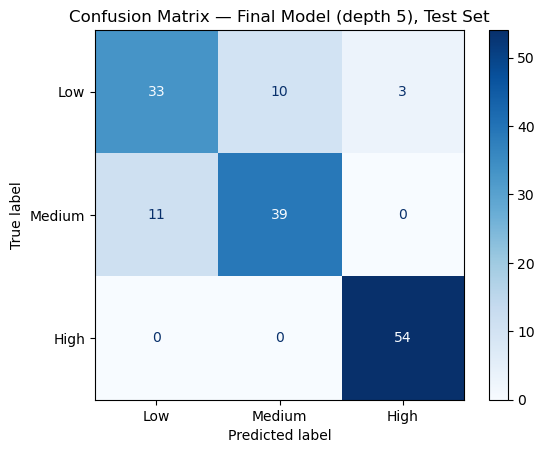

,precision,recall,f1-score,support
Low,0.750000,0.717000,0.733000,46.000000
Medium,0.796000,0.780000,0.788000,50.000000
High,0.947000,1.000000,0.973000,54.000000
accuracy,0.840000,0.840000,0.840000,0.840000
macro avg,0.831000,0.832000,0.831000,150.000000
weighted avg,0.836000,0.840000,0.838000,150.000000


In [53]:
# 6. Confusion matrix + per-class metrics (depth-5 final model).

y_pred = final.predict(X_test)

# -------------------------------------------------------------------------------------------------

# 6.1 3x3 confusion matrix.
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(cmap='Blues')
plt.title('Confusion Matrix — Final Model (depth 5), Test Set')
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------------------------------

# 6.2 Per-class precision/recall/f1 as a bordered table.
report = classification_report(y_test, y_pred,
                               target_names=['Low','Medium','High'],
                               output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
display(bordered(report_df, "Per-Class Metrics — Final Model (depth 5), Test Set"))

# -------------------------------------------------------------------------------------------------

# 6.3 Key findings.

# Perfect High-risk recall (1.00) is the key result. 54 actual High-risk patients, all 54 predicted High, zero misclassified.
# The costly error is a false negative on High risk, a genuinely high-risk worker who doesnt get flagged for monitoring.
# The model never misses a high-risk worker, which is precisely what a triage tool must guarantee. This validates the depth-5 model despite its 84% accuracy.

# Low-Medium confusion: 10 Lows predicted Medium, 11 Mediums predicted Low. 3 Lows predicted High — minor over-caution.
# Error structure favours safety — misclassifications cluster on the Low-Medium boundary and never cross from High to Low.
# The model's uncertainty is confined to low-stakes distinctions (reference the gini~0.49 leaves in the depth-5 tree as the source).

# The Low/Medium fuzziness is the honest limitation (precision/recall in the low 0.7s for the Low class).
# This reflects genuine overlap between low and medium risk profiles in this exposure data.
# Possibly because the features don't fully separate those two groups (and/or the young age skew muddies the lower-risk band).

# -------------------------------------------------------------------------------------------------


,Gini Importance
Passive Smoker,0.554400
Dust Allergy,0.392300
Air Pollution,0.030100
Age,0.023200
Gender,0.000000
OccuPational Hazards,0.000000


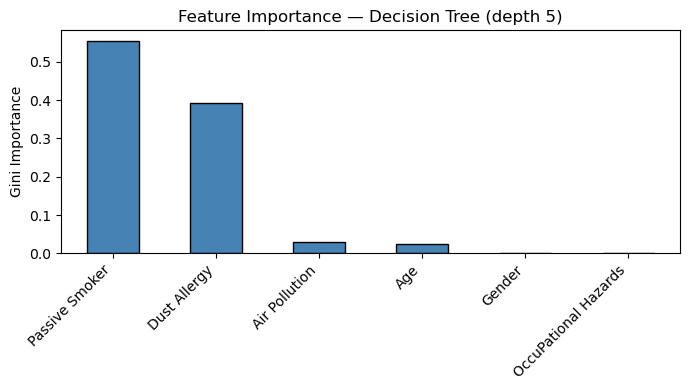

In [54]:
# 7. Feature importance (depth-5 final model).

# Gini importance: how much each feature reduced impurity across all the splits where it was used, normalised to sum to 1.
# Higher = the feature did more of the classification "work".

importances = pd.Series(final.feature_importances_, index=features).sort_values(ascending=False)

# -------------------------------------------------------------------------------------------------

# 7.1 Bordered table.
imp_table = importances.round(4).to_frame('Gini Importance')
display(bordered(imp_table, "Feature Importance — Final Model (depth 5)"))

# 7.2 Bar chart.
plt.figure(figsize=(7,4))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.ylabel('Gini Importance')
plt.title('Feature Importance — Decision Tree (depth 5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------------------------------

# 7.3 Key findings.

# Passive Smoker (0.554) and Dust Allergy (0.392) together account for 94.7% of all the model's predictive work.
# The other four contribute barely 5% combined. The six-variable model is, in effect, a two-variable model (with air pollution and age as minor tie-breakers).

# OccuPational Hazards = 0.000. The tree never split on it once.
# This is a result predicted from the correlation matrix, which can be used for a closed loop of analysis.
# Correlation matrix showed Dust Allergy ↔ Occupational Hazards = 0.84 (highly correlated).
# Tree structure showed Dust Allergy chosen repeatedly, Occupational Hazards never.
# Feature importance confirms it numerically: Dust Allergy 0.392, Occupational Hazards 0.000.
# Interpretation: correlated features don't add independent predictive power.
# The tree didn't judge Occupational Hazards unimportant in reality — it judged it redundant given Dust Allergy was already available.
# The two variables are largely measuring the same underlying thing (general environmental/occupational exposure burden).

# Gender = 0, so demographic sex was not a useful splitting variable once exposure variables were available.

# -------------------------------------------------------------------------------------------------

# 7.4 Conclusion.

# The model suggests a triage tool could rely primarily on two easily-collected questions (passive smoking, dust allergy) and still flag every high-risk worker.
# This is a  useful design insight for an occupational health screening instrument.
# A simpler instrument is cheaper and faster to deploy, which serves the low-cost triage goal set in AP1.

# -------------------------------------------------------------------------------------------------


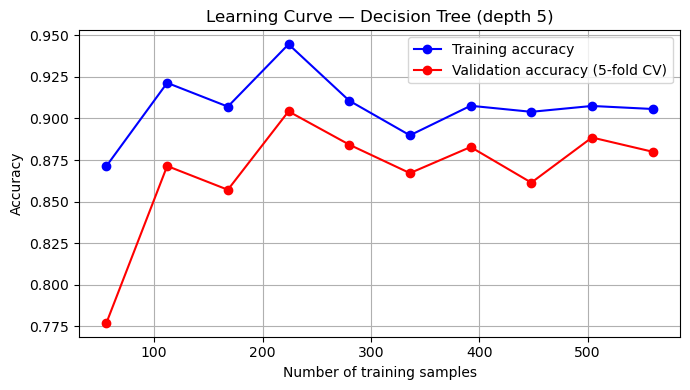

In [55]:

# 8. Learning curve (depth-5 final model)

# Plots accuracy vs the amount of training data used.
# Shows whether the model has enough data and whether it generalises (train and validation curves converging = healthy; large persistent gap = overfitting).

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=5, min_samples_split=2,
                           min_impurity_decrease=0, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),  # use 10%, 20%, ... 100% of training data
    cv=5,                                    # 5-fold cross-validation at each size
    scoring='accuracy',
    random_state=42)

# Average across the folds
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_mean, 'b-o', label='Training accuracy')
plt.plot(train_sizes, val_mean, 'r-o', label='Validation accuracy (5-fold CV)')
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Decision Tree (depth 5)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------------------------------------

# 8.1 Key Takeaway:

# The learning curve shows the training and validation accuracies converging to a small, stable gap (~0.90 and ~0.88) that plateaus beyond ~300 samples.
# This confirms the depth-5 model generalises well without significant overfitting and that the available training data is sufficient.

# -------------------------------------------------------------------------------------------------
